# SIR Model: Intuition Failures in R₀ Sensitivity

## Overview

The **SIR (Susceptible-Infected-Recovered)** model is the simplest compartmental epidemic model. This notebook builds from first principles and focuses on one central teaching goal:

**Small changes in R₀ produce nonlinear, large shifts in epidemic outcomes.** This illustrates two intuition failures:
1. **Nonlinearity**: A 10% increase in transmission does not yield a 10% increase in peak infections.
2. **Extrapolation failure**: Early exponential growth, if naively extrapolated, produces wildly inaccurate predictions.

We keep this notebook free of interventions; the goal is to establish **how R₀ controls the epidemic in an uncontrolled system**, which becomes the foundation for understanding interventions later.

**Note on derivation**: The SIR differential equations are shown below where relevant. Full mathematical derivation is linked in the appendix.

## Environment Setup and Reproducibility

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

# Utility: display parameter summary
def show_params(name, **kwargs):
    print(f"\n{name}:")
    for k, v in kwargs.items():
        if isinstance(v, float):
            print(f"  {k:20s} = {v:.6f}")
        else:
            print(f"  {k:20s} = {v}")

# Utility: plot compartments and incidence
def plot_sir_trajectory(times, S, I, R, incidence, title=""):
    fig = plt.figure(figsize=(14, 5))
    gs = GridSpec(1, 2, figure=fig)
    
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.plot(times, S, label="S (Susceptible)", linewidth=2, color="#1f77b4")
    ax0.plot(times, I, label="I (Infected)", linewidth=2, color="#ff7f0e")
    ax0.plot(times, R, label="R (Recovered)", linewidth=2, color="#2ca02c")
    ax0.set_xlabel("Time (days)", fontsize=11)
    ax0.set_ylabel("Count", fontsize=11)
    ax0.set_title("Compartment Trajectories", fontsize=12, fontweight='bold')
    ax0.legend(loc='best')
    ax0.grid(True, alpha=0.3)
    
    ax1 = fig.add_subplot(gs[0, 1])
    ax1.bar(times[:-1], incidence, width=1, alpha=0.7, color="#d62728", label="Daily incidence")
    ax1.set_xlabel("Time (days)", fontsize=11)
    ax1.set_ylabel("New infections", fontsize=11)
    ax1.set_title("Incidence (New Infections per Day)", fontsize=12, fontweight='bold')
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3, axis='y')
    
    if title:
        fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    return fig

## Define Core Epidemic State and Parameters

The SIR model tracks three compartments:
- **S** (Susceptible): individuals who can be infected
- **I** (Infected): individuals who are infectious
- **R** (Recovered): individuals who have recovered and are immune

The key parameter is **R₀** (basic reproduction number), defined as:
$$R_0 = \frac{\beta}{\gamma}$$

where:
- $\beta$ = transmission rate (contacts × probability of infection per contact, per unit time)
- $\gamma$ = recovery rate (1/infectious_period)

**Interpretation**: R₀ is the average number of people one infectious person will infect in a fully susceptible population.

In [2]:
# Baseline parameters
population_size = 10_000
initial_infected = 1
initial_recovered = 0
initial_susceptible = population_size - initial_infected - initial_recovered

# Disease parameters
infectious_period = 6.0  # days
gamma = 1.0 / infectious_period  # recovery rate

# Transmission parameter (baseline)
beta_baseline = 0.334  # contacts × transmission probability per day (gives R0 ~ 2)
R0_baseline = beta_baseline / gamma

# Simulation
duration = 100.0  # days
dt = 0.1  # time step
num_steps = int(duration / dt)
times = np.arange(0, duration + dt, dt)

# Display baseline configuration
show_params(
    "Baseline SIR Configuration",
    N=population_size,
    I0=initial_infected,
    R0_baseline=R0_baseline,
    infectious_period=infectious_period,
    gamma=gamma,
    beta_baseline=beta_baseline,
    duration=duration,
)

# Assumptions
print("\nAssumptions:")
print("  - No births or deaths (closed population)")
print("  - Homogeneous mixing (all individuals equally likely to contact)")
print("  - Infection confers permanent immunity (no waning)")
print("  - No interventions or policy changes during simulation")


Baseline SIR Configuration:
  N                    = 10000
  I0                   = 1
  R0_baseline          = 2.004000
  infectious_period    = 6.000000
  gamma                = 0.166667
  beta_baseline        = 0.334000
  duration             = 100.000000

Assumptions:
  - No births or deaths (closed population)
  - Homogeneous mixing (all individuals equally likely to contact)
  - Infection confers permanent immunity (no waning)
  - No interventions or policy changes during simulation


## Implement Baseline SIR Time-Step Simulation

The SIR differential equations are:
$$\frac{dS}{dt} = -\beta\frac{SI}{N}, \quad \frac{dI}{dt} = \beta\frac{SI}{N} - \gamma I, \quad \frac{dR}{dt} = \gamma I$$

We integrate these using a simple forward Euler method (Runge-Kutta 4 is available in the package, but we use Euler here for pedagogical clarity).

In [3]:
def simulate_sir(N, I0, R0_value, gamma, duration, dt):
    """
    Simulate SIR dynamics using forward Euler.
    
    Args:
        N: population size
        I0: initial infected count
        R0_value: basic reproduction number
        gamma: recovery rate (1/infectious_period)
        duration: simulation time in days
        dt: time step in days
    
    Returns:
        times, S, I, R, incidence
    """
    beta = R0_value * gamma
    S0 = N - I0
    R = 0
    
    S_traj = [S0]
    I_traj = [I0]
    R_traj = [R]
    incidence = []
    
    S, I = S0, I0
    
    for _ in range(int(duration / dt)):
        # SIR ODEs via Euler
        force_of_infection = beta * S * I / N
        dS = -force_of_infection
        dI = force_of_infection - gamma * I
        dR = gamma * I
        
        # Update
        S += dS * dt
        I += dI * dt
        R += dR * dt
        
        S_traj.append(max(0, S))
        I_traj.append(max(0, I))
        R_traj.append(max(0, R))
        incidence.append(max(0, force_of_infection * dt))
    
    times = np.arange(0, duration + dt, dt)
    return times[:len(S_traj)], np.array(S_traj), np.array(I_traj), np.array(R_traj), np.array(incidence)

# Run baseline scenario
times, S_base, I_base, R_base, inc_base = simulate_sir(
    N=population_size,
    I0=initial_infected,
    R0_value=R0_baseline,
    gamma=gamma,
    duration=duration,
    dt=dt,
)

# Check population conservation
pop_check = S_base + I_base + R_base
print(f"Population conservation check:")
print(f"  Initial total: {pop_check[0]:.1f}")
print(f"  Final total:   {pop_check[-1]:.1f}")
print(f"  Max deviation: {abs(pop_check - population_size).max():.1f} ({100*abs(pop_check - population_size).max()/population_size:.4f}%)")

Population conservation check:
  Initial total: 10000.0
  Final total:   10000.0
  Max deviation: 0.0 (0.0000%)


## Track and Visualize S(t), I(t), R(t) and Incidence

Run the baseline scenario and visualize the compartment trajectories and daily incidence.

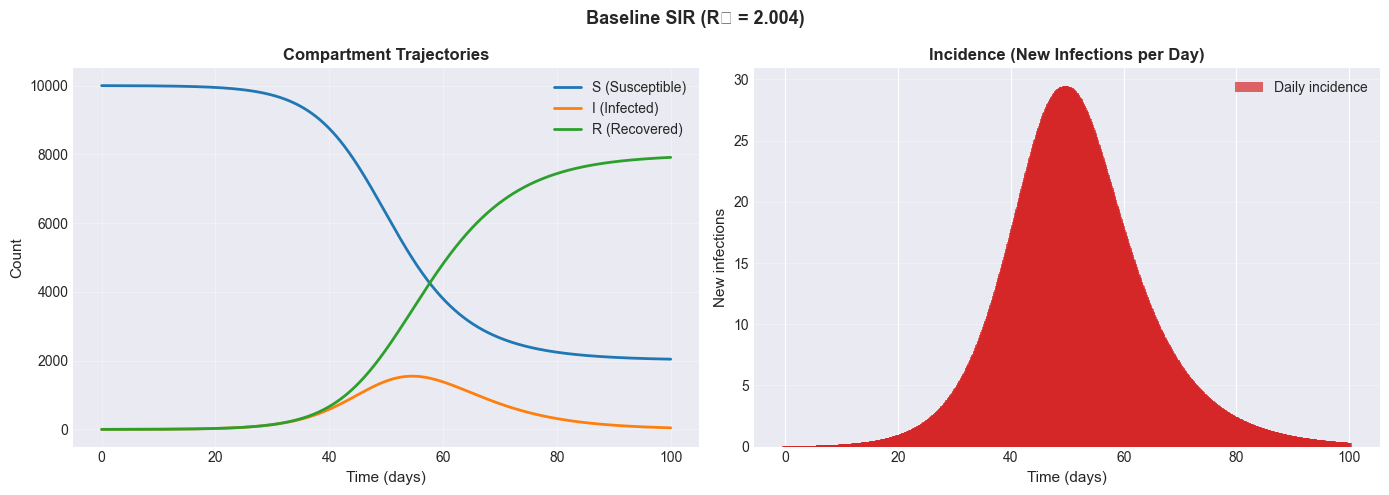


Baseline SIR Outcomes (R₀ = 2.004):
  Peak infected:      1547.8 individuals (15.48%)
  Time to peak:         54.6 days
  Final attack rate:  7911.9 individuals (79.12%)


In [4]:
fig = plot_sir_trajectory(times, S_base, I_base, R_base, inc_base, 
                          title=f"Baseline SIR (R₀ = {R0_baseline:.3f})")
plt.show()

# Extract key metrics
I_peak_idx = np.argmax(I_base)
I_peak = I_base[I_peak_idx]
t_peak = times[I_peak_idx]
peak_pct = 100 * I_peak / population_size
final_attacked = R_base[-1]
attack_rate = 100 * final_attacked / population_size

print(f"\nBaseline SIR Outcomes (R₀ = {R0_baseline:.3f}):")
print(f"  Peak infected:     {I_peak:7.1f} individuals ({peak_pct:5.2f}%)")
print(f"  Time to peak:      {t_peak:7.1f} days")
print(f"  Final attack rate: {final_attacked:7.1f} individuals ({attack_rate:5.2f}%)")

## Compute R₀, Effective Reproduction Rₜ, and Growth Indicators

**Effective reproduction number** at time $t$ is:
$$R_t = R_0 \cdot \frac{S(t)}{N}$$

This represents how many people one infected person will infect at time $t$, accounting for the depletion of susceptibles. When $R_t < 1$, the epidemic begins to decline.

We also compute a **doubling-time proxy** in the early exponential phase to show how quickly the outbreak initially spreads.

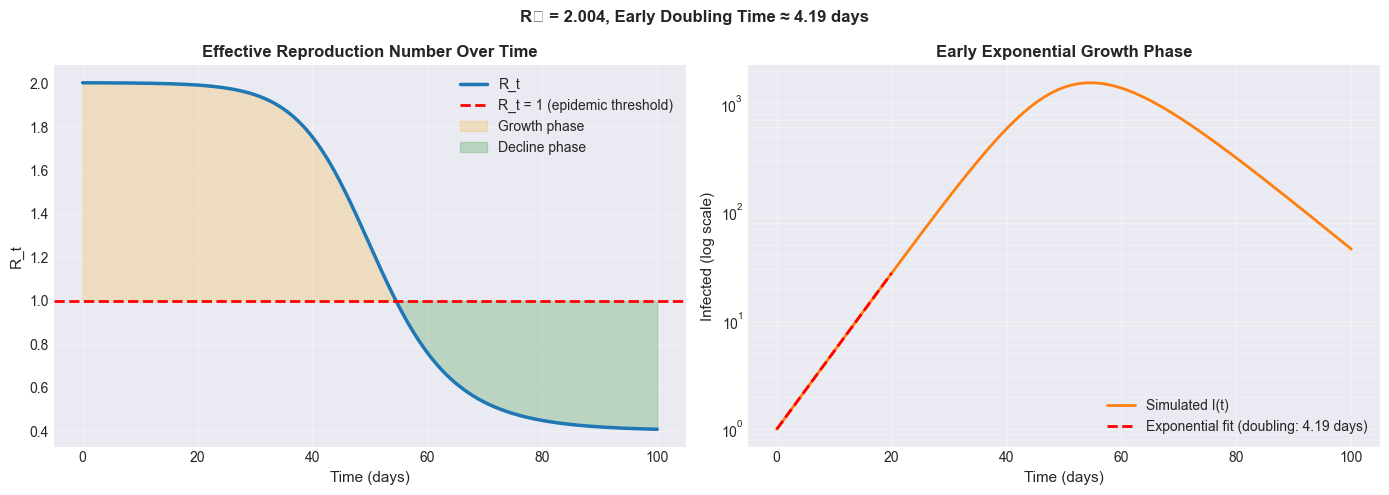

In [5]:
# Compute effective reproduction
R_t = R0_baseline * S_base / population_size

# Compute growth rate (early exponential phase, first 20 days)
early_window = times <= 20
I_early = I_base[early_window]
times_early = times[early_window]

if len(I_early) > 1 and np.all(I_early > 0):
    log_I = np.log(I_early)
    coeffs = np.polyfit(times_early, log_I, 1)
    growth_rate_early = coeffs[0]
    doubling_time_early = np.log(2) / max(growth_rate_early, 1e-6)
else:
    growth_rate_early = np.nan
    doubling_time_early = np.nan

# Visualize R_t and growth
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R_t trajectory
ax = axes[0]
ax.plot(times, R_t, linewidth=2.5, color="#1f77b4", label="R_t")
ax.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label="R_t = 1 (epidemic threshold)")
ax.fill_between(times, 1.0, R_t, where=(R_t >= 1), alpha=0.2, color='orange', label="Growth phase")
ax.fill_between(times, 1.0, R_t, where=(R_t < 1), alpha=0.2, color='green', label="Decline phase")
ax.set_xlabel("Time (days)", fontsize=11)
ax.set_ylabel("R_t", fontsize=11)
ax.set_title("Effective Reproduction Number Over Time", fontsize=12, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# Early exponential fit
ax = axes[1]
ax.semilogy(times, I_base, linewidth=2, color="#ff7f0e", label="Simulated I(t)")
if not np.isnan(doubling_time_early):
    I_fit = I_early[0] * np.exp(growth_rate_early * (times_early - times_early[0]))
    ax.semilogy(times_early, I_fit, 'r--', linewidth=2, label=f"Exponential fit (doubling: {doubling_time_early:.2f} days)")
ax.set_xlabel("Time (days)", fontsize=11)
ax.set_ylabel("Infected (log scale)", fontsize=11)
ax.set_title("Early Exponential Growth Phase", fontsize=12, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3, which='both')

fig.suptitle(f"R₀ = {R0_baseline:.3f}, Early Doubling Time ≈ {doubling_time_early:.2f} days", 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## R₀ Sensitivity Sweep: Nonlinear Outcome Divergence

This is the **central pedagogical section**. We vary R₀ across a range (1.2 to 3.0) and measure how peak infected count, time to peak, and total attack rate change.

The goal is to show that outcomes are **highly nonlinear** with respect to R₀, which violates many people's intuitions about proportional relationships.

R₀ Sensitivity Sweep Results:
 R0      I_peak  t_peak  attack_rate
1.2   25.618849   100.0   129.133075
1.4  369.716141   100.0  1327.419773
1.6  815.271709    83.5  4899.745850
1.8 1183.474851    66.0  6993.782595
2.0 1540.868594    54.8  7898.897045
2.2 1879.604732    47.0  8426.109920
2.4 2197.049066    41.2  8789.641101
2.6 2492.917647    36.7  9056.978650
2.8 2768.257658    33.2  9259.151817
3.0 3024.300749    30.3  9414.441567



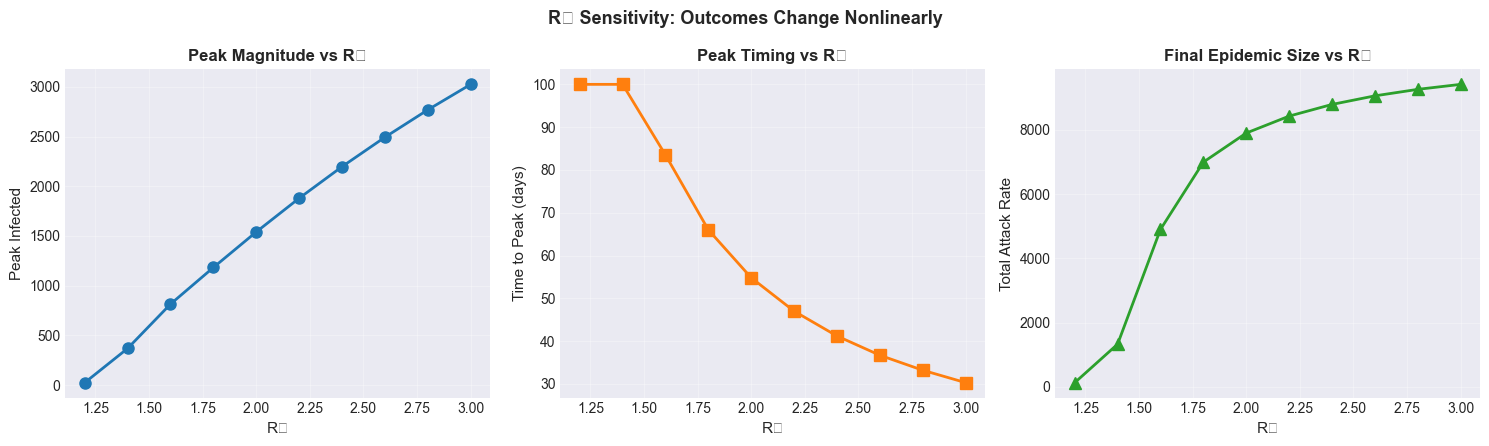

In [6]:
# Sweep across R₀ values
R0_values = np.linspace(1.2, 3.0, 10)
sweep_results = []

for r0 in R0_values:
    times_r, S_r, I_r, R_r, inc_r = simulate_sir(
        N=population_size, I0=initial_infected, R0_value=r0,
        gamma=gamma, duration=duration, dt=dt
    )
    
    I_peak_r = np.max(I_r)
    t_peak_r = times_r[np.argmax(I_r)]
    attack_rate_r = R_r[-1]
    
    sweep_results.append({
        'R0': r0,
        'I_peak': I_peak_r,
        't_peak': t_peak_r,
        'attack_rate': attack_rate_r,
    })

df_sweep = pd.DataFrame(sweep_results)

print("R₀ Sensitivity Sweep Results:")
print(df_sweep.to_string(index=False))
print()

# Visualize sweep outcomes
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Peak infected vs R₀
ax = axes[0]
ax.plot(df_sweep['R0'], df_sweep['I_peak'], 'o-', linewidth=2, markersize=8, color="#1f77b4")
ax.set_xlabel("R₀", fontsize=11)
ax.set_ylabel("Peak Infected", fontsize=11)
ax.set_title("Peak Magnitude vs R₀", fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Time to peak vs R₀
ax = axes[1]
ax.plot(df_sweep['R0'], df_sweep['t_peak'], 's-', linewidth=2, markersize=8, color="#ff7f0e")
ax.set_xlabel("R₀", fontsize=11)
ax.set_ylabel("Time to Peak (days)", fontsize=11)
ax.set_title("Peak Timing vs R₀", fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Attack rate vs R₀
ax = axes[2]
ax.plot(df_sweep['R0'], df_sweep['attack_rate'], '^-', linewidth=2, markersize=8, color="#2ca02c")
ax.set_xlabel("R₀", fontsize=11)
ax.set_ylabel("Total Attack Rate", fontsize=11)
ax.set_title("Final Epidemic Size vs R₀", fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

fig.suptitle("R₀ Sensitivity: Outcomes Change Nonlinearly", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Intuition Failure Demo: Small R₀ Changes, Large Outcome Shifts

**The core lesson**: a 20% increase in R₀ does not produce a 20% increase in peak infections. It often produces much larger shifts, which violates naive linear thinking.

Pick two nearby R₀ values and show the divergence in outcomes.

Intuition Failure Demonstration:
  R₀ change: 1.50 → 1.80 (a 20.0% increase)
  Peak infected change: 632 → 1183 (+87.2% change)
  Attack rate change: 3060 → 6994 (+128.6% change)

  ⚠️  A 20.0% increase in R₀ produced a 87.2% increase in peak infections!



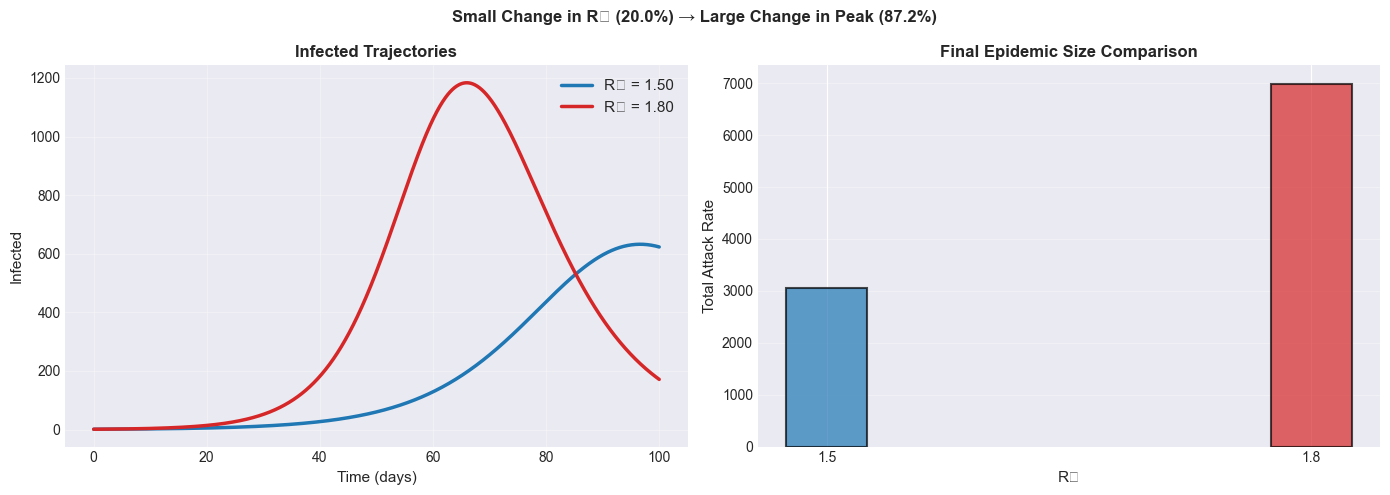

In [7]:
# Pick two nearby scenarios
R0_low = 1.5
R0_high = 1.8
rel_change = 100 * (R0_high - R0_low) / R0_low

times_low, S_low, I_low, R_low, inc_low = simulate_sir(
    N=population_size, I0=initial_infected, R0_value=R0_low,
    gamma=gamma, duration=duration, dt=dt
)

times_high, S_high, I_high, R_high, inc_high = simulate_sir(
    N=population_size, I0=initial_infected, R0_value=R0_high,
    gamma=gamma, duration=duration, dt=dt
)

I_peak_low = np.max(I_low)
I_peak_high = np.max(I_high)
peak_change_pct = 100 * (I_peak_high - I_peak_low) / I_peak_low

attack_low = R_low[-1]
attack_high = R_high[-1]
attack_change_pct = 100 * (attack_high - attack_low) / attack_low

print(f"Intuition Failure Demonstration:")
print(f"  R₀ change: {R0_low:.2f} → {R0_high:.2f} (a {rel_change:.1f}% increase)")
print(f"  Peak infected change: {I_peak_low:.0f} → {I_peak_high:.0f} ({peak_change_pct:+.1f}% change)")
print(f"  Attack rate change: {attack_low:.0f} → {attack_high:.0f} ({attack_change_pct:+.1f}% change)")
print()
print(f"  ⚠️  A {rel_change:.1f}% increase in R₀ produced a {peak_change_pct:.1f}% increase in peak infections!")
print()

# Plot overlaid trajectories
fig = plt.figure(figsize=(14, 5))
gs = GridSpec(1, 2, figure=fig)

ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(times_low, I_low, linewidth=2.5, label=f"R₀ = {R0_low:.2f}", color="#1f77b4")
ax0.plot(times_high, I_high, linewidth=2.5, label=f"R₀ = {R0_high:.2f}", color="#d62728")
ax0.set_xlabel("Time (days)", fontsize=11)
ax0.set_ylabel("Infected", fontsize=11)
ax0.set_title("Infected Trajectories", fontsize=12, fontweight='bold')
ax0.legend(fontsize=11)
ax0.grid(True, alpha=0.3)

ax1 = fig.add_subplot(gs[0, 1])
ax1.bar([R0_low, R0_high], [attack_low, attack_high], width=0.05, alpha=0.7, 
        color=["#1f77b4", "#d62728"], edgecolor="black", linewidth=1.5)
ax1.set_xlabel("R₀", fontsize=11)
ax1.set_ylabel("Total Attack Rate", fontsize=11)
ax1.set_title("Final Epidemic Size Comparison", fontsize=12, fontweight='bold')
ax1.set_xticks([R0_low, R0_high])
ax1.grid(True, alpha=0.3, axis='y')

fig.suptitle(f"Small Change in R₀ ({rel_change:.1f}%) → Large Change in Peak ({peak_change_pct:.1f}%)", 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Extrapolation Failure Demo: Early Exponential Fit vs Reality

**The problem**: Early in an outbreak, case counts look exponential. If you fit exponential growth to early data and extrapolate forward, you typically **overestimate** future cases because you ignore the depletion of susceptibles.

We fit exponential growth to the first 10 days and project it forward to 100 days, then compare against the full simulated trajectory.

Extrapolation Failure Demo (R₀ = 2.50):
  Fitted exponential growth rate (first 10 days): 0.2467 per day
  Doubling time (from fit): 2.81 days

  At t = 30 days:
    Actual infected:         1124
    Extrapolated (naive):     1638
    Overestimate:           +45.7%

  ⚠️  Naive exponential extrapolation overestimates by 46%!
      This is because susceptibles are depleted, slowing transmission.



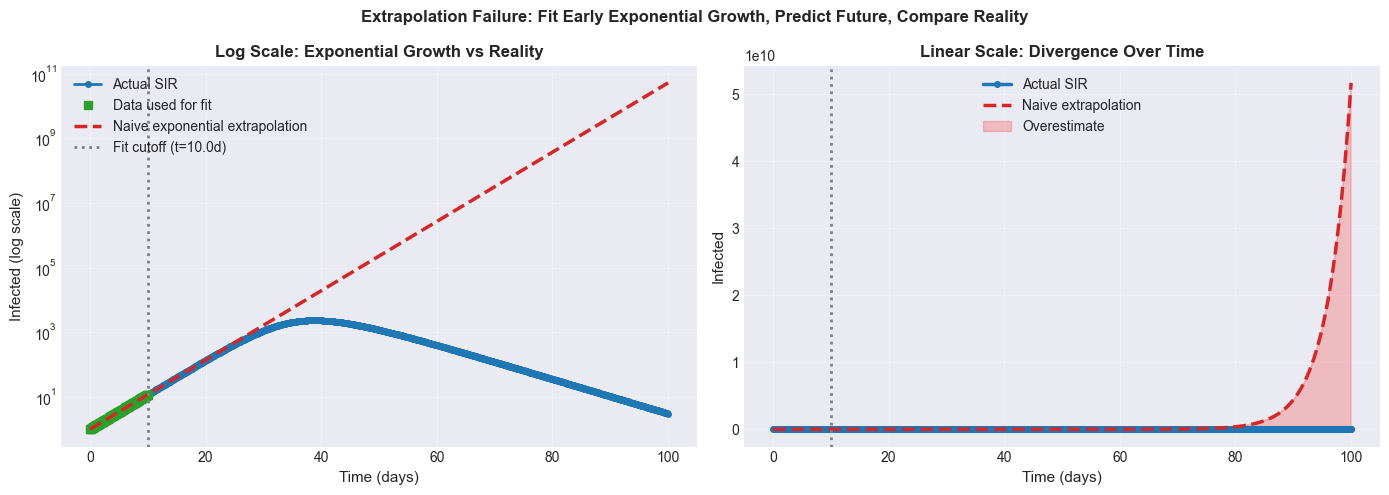

In [8]:
# Use the baseline run (R₀ ≈ 0.3, but let's use a higher R₀ for clearer dynamics)
R0_demo = 2.5
times_demo, S_demo, I_demo, R_demo, inc_demo = simulate_sir(
    N=population_size, I0=initial_infected, R0_value=R0_demo,
    gamma=gamma, duration=duration, dt=dt
)

# Fit exponential to early window (first 10 days)
early_cutoff = 10.0
early_mask = times_demo <= early_cutoff
times_early_demo = times_demo[early_mask]
I_early_demo = I_demo[early_mask]

# Fit exponential: I(t) = I0 * exp(r*t)
if np.all(I_early_demo > 0):
    log_I_early = np.log(I_early_demo)
    coeffs_exp = np.polyfit(times_early_demo, log_I_early, 1)
    r_early = coeffs_exp[0]
    I0_fit = np.exp(coeffs_exp[1])
    
    # Extrapolate the fit to full duration
    I_extrap = I0_fit * np.exp(r_early * times_demo)
else:
    I_extrap = np.zeros_like(times_demo)

# Compare early fit prediction vs reality
t_compare = 30.0
idx_compare = np.argmin(np.abs(times_demo - t_compare))
I_real_30 = I_demo[idx_compare]
I_extrap_30 = I_extrap[idx_compare]
overestimate_pct = 100 * (I_extrap_30 - I_real_30) / I_real_30

print(f"Extrapolation Failure Demo (R₀ = {R0_demo:.2f}):")
print(f"  Fitted exponential growth rate (first 10 days): {r_early:.4f} per day")
print(f"  Doubling time (from fit): {np.log(2)/r_early:.2f} days")
print(f"")
print(f"  At t = 30 days:")
print(f"    Actual infected:      {I_real_30:7.0f}")
print(f"    Extrapolated (naive):  {I_extrap_30:7.0f}")
print(f"    Overestimate:         {overestimate_pct:+7.1f}%")
print()
print(f"  ⚠️  Naive exponential extrapolation overestimates by {overestimate_pct:.0f}%!")
print(f"      This is because susceptibles are depleted, slowing transmission.")
print()

# Visualize extrapolation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log scale to show exponential fit
ax = axes[0]
ax.semilogy(times_demo, I_demo, 'o-', linewidth=2, markersize=4, label="Actual SIR", color="#1f77b4")
ax.semilogy(times_early_demo, I_early_demo, 's', markersize=6, label="Data used for fit", color="#2ca02c")
ax.semilogy(times_demo, I_extrap, '--', linewidth=2.5, label="Naive exponential extrapolation", color="#d62728")
ax.axvline(x=early_cutoff, color='gray', linestyle=':', linewidth=2, label=f"Fit cutoff (t={early_cutoff}d)")
ax.set_xlabel("Time (days)", fontsize=11)
ax.set_ylabel("Infected (log scale)", fontsize=11)
ax.set_title("Log Scale: Exponential Growth vs Reality", fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3, which='both')

# Linear scale showing divergence
ax = axes[1]
ax.plot(times_demo, I_demo, 'o-', linewidth=2.5, markersize=4, label="Actual SIR", color="#1f77b4")
ax.plot(times_demo, I_extrap, '--', linewidth=2.5, label="Naive extrapolation", color="#d62728")
ax.fill_between(times_demo, I_demo, I_extrap, where=(I_extrap >= I_demo), 
                alpha=0.2, color='red', label="Overestimate")
ax.axvline(x=early_cutoff, color='gray', linestyle=':', linewidth=2)
ax.set_xlabel("Time (days)", fontsize=11)
ax.set_ylabel("Infected", fontsize=11)
ax.set_title("Linear Scale: Divergence Over Time", fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3)

fig.suptitle("Extrapolation Failure: Fit Early Exponential Growth, Predict Future, Compare Reality", 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary and Takeaways

### What We've Learned

1. **R₀ controls the epidemic outcome**: When R₀ > 1, the epidemic grows; when R₀ < 1, it fades.

2. **Nonlinearity**: Small changes in R₀ produce nonlinear (often surprisingly large) changes in peak infections and total attack rate. This violates naive proportional thinking.

3. **Effective reproduction R_t < 1 marks the decline**: As susceptibles are depleted, R_t falls. Once R_t < 1, new infections decline even if R₀ remains unchanged.

4. **Early exponential growth is misleading**: If you fit exponential growth to early data and naively extrapolate, you typically overestimate future cases because you ignore susceptible depletion.

### Intuition Failures Illustrated

- **Proportional thinking** is wrong: 20% increase in R₀ ≠ 20% increase in peak
- **Extrapolation blindness**: Early exponential fit predicts the future poorly because it ignores the fundamental mechanism (susceptible depletion)

### Next Steps

The SIR model assumes instant recovery (no latent period) and lifelong immunity (no waning). In the next notebook, we add a latent period (SEIR) to show how disease-specific properties (like incubation time) affect epidemiologytiming, even when R₀ stays the same.

---

## Appendix: SIR Model Equations and Derivation

The SIR model consists of three coupled ordinary differential equations:

$$\frac{dS}{dt} = -\beta \frac{SI}{N}$$

$$\frac{dI}{dt} = \beta \frac{SI}{N} - \gamma I$$

$$\frac{dR}{dt} = \gamma I$$

with initial conditions $S(0) = S_0$, $I(0) = I_0$, $R(0) = 0$, and $N = S + I + R$ (conserved).

**Key quantities:**
- $\beta$: transmission rate (per capita per day)
- $\gamma$: recovery rate (per capita per day); related to infectious period as $\gamma = 1/\tau_I$
- $R_0 = \beta/\gamma$: basic reproduction number

**Interpretation:**
- The term $-\beta SI/N$ represents the rate at which susceptibles become infected (proportional to contact rate and fraction infected)
- The term $-\gamma I$ represents the rate at which infected individuals recover
- Population is closed (no births, deaths, or migration)

For a full mathematical derivation and discussion of assumptions, see standard epidemiological texts (e.g., Keeling & Rohani, Anderson & May, or Vynnycky & White).